In [ ]:
import os
import whisper
from transformers import pipeline
import gradio as gr
from sentence_transformers import SentenceTransformer
import numpy as np
import faiss
import numpy as np
from transformers import AutoTokenizer, AutoModel
from transformers import pipeline
from pyannote.audio import Pipeline
from speechbrain.pretrained import SpeakerRecognition
from speechbrain.pretrained import EncoderClassifier

from pydub import AudioSegment
import csv
import json
import librosa
import soundfile as sf


# Set your Hugging Face token
HUGGING_FACE_TOKEN = ""
from speechbrain.pretrained import EncoderClassifier

/Users/ghs6kor/miniconda3/envs/dl_lab_py310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:speechbrain.utils.quirks:Applied quirks (see `speechbrain.utils.quirks`): [allow_tf32, disable_jit_profiling]
INFO:speechbrain.utils.quirks:Excluded quirks specified by the `SB_DISABLE_QUIRKS` environment (comma-separated list): []
/var/folders/2d/mf93wtk914vbrkclc8d3hrt40000gn/T/ipykernel_21001/2449011178.py:12: UserWarning: Module 'speechbrain.pretrained' was deprecated, redirecting to 'speechbrain.inference'. Please update your script. This is a change from SpeechBrain 1.0. See: https://github.com/speechbrain/speechbrain/releases/tag/v1.0.0
  from speechbrain.pretrained import SpeakerRecognition


# Converting to 16kHZ

In [5]:
# Load the audio file
y, sr = librosa.load("audio_only_trump_biden.wav", sr=44100)  # Original sample rate

# Resample to 16 kHz
y_resampled = librosa.resample(y, orig_sr=sr, target_sr=16000)

# Save the resampled audio
sf.write("audio_only_trump_biden_16k.wav", y_resampled, 16000)

# Emotion Detection

In [53]:
# Process Audio segments
def parse_rttm(file_path):
    segments = []
    with open(file_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            start_time = float(parts[3])  # Start time in seconds
            duration = float(parts[4])    # Duration in seconds
            speaker_id = parts[7]         # Speaker ID
            end_time = start_time + duration
            segments.append({
                "start_time": start_time,
                "end_time": end_time,
                "speaker_id": speaker_id
            })
    return segments

def extract_segment(audio, start_time, end_time):
    start_ms = int(start_time * 1000)  # Convert to milliseconds
    end_ms = int(end_time * 1000)      # Convert to milliseconds
    return audio[start_ms:end_ms]


# Step 4: Classify emotions
def classify_emotion(audio_segment):
    # Preprocess the audio
    audio_segment = preprocess_audio(audio_segment)
    
    # Export the segment to a temporary file
    audio_segment.export("temp.wav", format="wav")
    
    # Classify emotion for the segment
    emotion_probabilities = classifier.classify_file("temp.wav")
    predicted_emotion = classifier.hparams.label_encoder.decode_torch(
        np.argmax(emotion_probabilities, axis=-1)
    )[0]
    return predicted_emotion


# Parse the RTTM file
segments = parse_rttm("audio_sd.rttm")

# Load the audio file
audio = AudioSegment.from_file("audio_only_trump_biden_16k.wav")

# Extract segments for each speaker
for segment in segments:
    segment["audio"] = extract_segment(audio, segment["start_time"], segment["end_time"])

In [125]:
# Extract Audio Segments
from pydub import AudioSegment

# Load the full audio file
audio = AudioSegment.from_file("audio.wav")

# Extract audio segments for each speaker
speaker_segments = {}
for segment in segments:
    start_time = int(segment["start_time"] * 1000)  # Convert to milliseconds
    end_time = int(segment["end_time"] * 1000)      # Convert to milliseconds
    speaker_id = segment["speaker_id"]
    speaker_segments.setdefault(speaker_id, []).append(audio[start_time:end_time])


# Preprocess audio segments
for speaker_id, segments in speaker_segments.items():
    for i, segment in enumerate(segments):
        segment = segment.set_frame_rate(16000).set_channels(1)  # Convert to 16 kHz mono
        segment.export(f"speaker_{speaker_id}_segment_{i}.wav", format="wav")

In [133]:


# Load the emotion recognition model
# emotion_classifier = EncoderClassifier.from_hparams(
#     source="speechbrain/emotion-recognition-wav2vec2-IEMOCAP",
#     savedir="pretrained_models/emotion-recognition-wav2vec2-IEMOCAP"
# )

# Example: Use a different model
emotion_classifier = EncoderClassifier.from_hparams(
    source="speechbrain/spkrec-ecapa-voxceleb",  # Example model
    savedir="pretrained_models/spkrec-ecapa-voxceleb"
)

INFO:speechbrain.utils.fetching:Fetch hyperparams.yaml: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached
INFO:speechbrain.utils.fetching:Fetch custom.py: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached
INFO:speechbrain.utils.fetching:Fetch embedding_model.ckpt: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached
INFO:speechbrain.utils.fetching:Fetch mean_var_norm_emb.ckpt: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached
INFO:speechbrain.utils.fetching:Fetch classifier.ckpt: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached
INFO:speechbrain.utils.fetching:Fetch label_encoder.txt: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached
INFO:speechbrain.utils.parameter_transfer:Loading pretrained files for: embedding_model, mean_var_norm_emb, classifier, label_encoder


In [134]:
from pydub import AudioSegment
from speechbrain.pretrained import EncoderClassifier

# Load the audio file
audio = AudioSegment.from_file("audio.wav")

# Check the duration of the audio
duration = len(audio) / 1000  # Duration in seconds
print(f"Audio Duration: {duration} seconds")

# Pad the audio to a minimum duration (e.g., 2 seconds)
min_duration = 2000  # 2 seconds in milliseconds
if len(audio) < min_duration:
    silence = AudioSegment.silent(duration=min_duration - len(audio))
    audio = audio + silence

# Save the padded audio
audio.export("padded_audio.wav", format="wav")

# Load the ECAPA-TDNN model
emotion_classifier = EncoderClassifier.from_hparams(
    source="speechbrain/spkrec-ecapa-voxceleb",
    savedir="pretrained_models/spkrec-ecapa-voxceleb"
)

# Analyze emotion for the padded audio file
emotion = emotion_classifier.classify_file("padded_audio.wav")
print(f"Detected Emotion: {emotion}")

INFO:speechbrain.utils.fetching:Fetch hyperparams.yaml: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached


Audio Duration: 5428.57 seconds


INFO:speechbrain.utils.fetching:Fetch custom.py: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached
INFO:speechbrain.utils.fetching:Fetch embedding_model.ckpt: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached
INFO:speechbrain.utils.fetching:Fetch mean_var_norm_emb.ckpt: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached
INFO:speechbrain.utils.fetching:Fetch classifier.ckpt: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached
INFO:speechbrain.utils.fetching:Fetch label_encoder.txt: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached
INFO:speechbrain.utils.parameter_transfer:Loading pretrained files for: embedding_model, mean_var_norm_emb, classifier, label_encoder


: 

In [132]:
# from speechbrain.pretrained import EncoderClassifier

# # Load the pre-trained emotion recognition model
# emotion_classifier = EncoderClassifier.from_hparams(
#     source="speechbrain/emotion-recognition-wav2vec2-IEMOCAP",
#     savedir="pretrained_models/emotion-recognition-wav2vec2-IEMOCAP"
# )

# Analyze emotions for each speaker segment
speaker_emotions = {}
for speaker_id, segments in speaker_segments.items():
    speaker_emotions[speaker_id] = []
    for i, segment in enumerate(segments):
        segment_path = f"speaker_{speaker_id}_segment_{i}.wav"
        emotion = emotion_classifier.classify_file(segment_path)
        speaker_emotions[speaker_id].append(emotion)


# # Classify emotions for each segment
# for segment in segments:
#     segment["emotion"] = classify_emotion(segment["audio"])

# # Save results to CSV
# output_csv = "emotion_timeline.csv"
# with open(output_csv, mode="w", newline="") as file:
#     writer = csv.writer(file)
#     writer.writerow(["Speaker ID", "Start Time (s)", "End Time (s)", "Emotion"])
#     for segment in segments:
#         writer.writerow([
#             segment["speaker_id"],
#             segment["start_time"],
#             segment["end_time"],
#             segment["emotion"]
#         ])
# print(f"Emotion timeline saved to {output_csv}")

# # Save results to JSON
# output_json = "emotion_timeline.json"
# with open(output_json, mode="w") as file:
#     json.dump(segments, file, indent=4)
# print(f"Emotion timeline saved to {output_json}")

RuntimeError: Argument #4: Padding size should be less than the corresponding input dimension, but got: padding (4, 4) at dimension 2 of input [1, 128, 4]

# Fact Verification

The goal is to validate the facts which was in the debate

## Transcription Generation

In [18]:

# Load the Whisper model
model = whisper.load_model("medium")  # Use "small" or "medium" for better accuracy

# Transcribe the audio file
def transcribe_audio(audio_path):
    # Transcribe the audio
    result = model.transcribe(audio_path)
    return result["segments"]

# Save the transcription in JSON format
def save_transcription_json(segments, output_path):
    with open(output_path, "w") as f:
        json.dump(segments, f, indent=4)

# Save the transcription in plain text format with timestamps
def save_transcription_text(segments, output_path):
    with open(output_path, "w") as f:
        for segment in segments:
            f.write(f"[{segment['start']:.3f} - {segment['end']:.3f}] {segment['text']}\n")

# Example usage
audio_path = "audio_only_trump_biden_16k.wav"  # Path to the audio file
transcription_segments = transcribe_audio(audio_path)

# Save the transcription in JSON format
save_transcription_json(transcription_segments, "transcription.json")

# Save the transcription in plain text format with timestamps
save_transcription_text(transcription_segments, "transcription.txt")

print("Transcription saved to transcription.json and transcription.txt")

100%|█████████████████████████████████████| 1.42G/1.42G [01:50<00:00, 13.9MiB/s]
/Users/ghs6kor/miniconda3/envs/dl_lab_py310/lib/python3.10/site-packages/whisper/transcribe.py:126: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


Transcription saved to transcription.json and transcription.txt


## Parsing the transcription

In [20]:
import json

# Load the transcription JSON file
with open("transcription.json", "r") as f:
    transcription_data = json.load(f)

# Convert to the required format
transcription = [
    {
        "start_time": segment["start"],
        "end_time": segment["end"],
        "text": segment["text"].strip()
    }
    for segment in transcription_data
]

# Print the converted transcription
print(transcription)

[{'start_time': 0.0, 'end_time': 6.0, 'text': "Good evening. I'm Dana Bash, anchor of CNN's Inside Politics and co-anchor of State of the Union."}, {'start_time': 6.0, 'end_time': 10.0, 'text': "I'm Jake Tapper, anchor of CNN's The Lead and co-anchor of State of the Union."}, {'start_time': 10.0, 'end_time': 18.0, 'text': 'Dana and I will co-moderate this evening. Our job is to facilitate a debate between the two candidates tonight.'}, {'start_time': 18.0, 'end_time': 22.0, 'text': 'Before we introduce them, we want to share the rules of the debate with the audience at home.'}, {'start_time': 22.0, 'end_time': 25.0, 'text': 'Former President Trump will be on the left side of the screen.'}, {'start_time': 25.0, 'end_time': 30.0, 'text': 'President Biden will be appearing on the right, a coin toss, determined their positions.'}, {'start_time': 30.0, 'end_time': 37.0, 'text': 'Each candidate will have two minutes to answer a question and one minute each for responses and rebuttals.'}, {'s

# Match Speaker Segments

In [110]:
def parse_rttm(file_path):
    segments = []
    with open(file_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            start_time = float(parts[3])  # Start time in seconds
            duration = float(parts[4])    # Duration in seconds
            speaker_id = parts[7]         # Speaker ID
            if speaker_id == "SPEAKER_01" : 
                speaker_id = "Joe Biden"
                end_time = start_time + duration
                segments.append({
                    "start_time": start_time,
                    "end_time": end_time,
                    "speaker_id": speaker_id
                })
                #print("Biden")
            elif speaker_id == "SPEAKER_03" : 
                speaker_id = "Donald Trump"
                #print("Trump")
                end_time = start_time + duration
                segments.append({
                    "start_time": start_time,
                    "end_time": end_time,
                    "speaker_id": speaker_id
                })
    return segments

# Match speaker segments with transcribed text
def match_transcription(segments, transcription):
    for segment in segments:
        for entry in transcription:
            if (segment["start_time"] <= entry["start_time"] and
                segment["end_time"] >= entry["end_time"]):
                segment["text"] = entry["text"]
                break
        else:
            segment["text"] = ""  # No matching text found

# Parse the RTTM file
segments = parse_rttm("audio_sd.rttm")
print(segments[12])

# Match speaker segments with transcribed text
match_transcription(segments, transcription)
print(segments[12])

{'start_time': 677.613, 'end_time': 732.254, 'speaker_id': 'Donald Trump'}
{'start_time': 677.613, 'end_time': 732.254, 'speaker_id': 'Donald Trump', 'text': "They're putting them on Medicare. They're putting them on Social Security. They're going to destroy Social Security."}


# Verify with prompt

### LLama

In [34]:
from transformers import AutoTokenizer, AutoModelForCausalLM

# Load the Llama tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(
    "meta-llama/Llama-2-7b-chat-hf",
    use_auth_token=HUGGING_FACE_TOKEN
)
model = AutoModelForCausalLM.from_pretrained(
    "meta-llama/Llama-2-7b-chat-hf",
    use_auth_token=HUGGING_FACE_TOKEN)


Loading checkpoint shards: 100%|██████████| 2/2 [00:28<00:00, 14.32s/it]


In [111]:
segments[12]

{'start_time': 677.613,
 'end_time': 732.254,
 'speaker_id': 'Donald Trump',
 'text': "They're putting them on Medicare. They're putting them on Social Security. They're going to destroy Social Security."}

In [112]:
# Create a prompt for fact verification
def create_prompt(text, speaker):
    return f"Verify the factual accuracy of the following statement: '{text}' spoken by '{speaker}'. Provide response in three ways yes/no/not sure. Also in case of 'yes', please provide the relevant documents/links used for validating the fact"

# Function to verify facts using Llama
def llama_verify_fact(prompt):
    inputs = tokenizer(prompt, return_tensors="pt")
    outputs = model.generate(**inputs, max_new_tokens=100)
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return response


# Verify facts for each segment using Llama
for segment in segments[12:13]:
    segment["prompt"] = create_prompt(segment["text"], segment["speaker_id"])
    segment["verification"] = llama_verify_fact(segment["prompt"])
    print(segment["verification"])
    break
    #print ("segment is none")


Verify the factual accuracy of the following statement: 'They're putting them on Medicare. They're putting them on Social Security. They're going to destroy Social Security.' spoken by 'Donald Trump'. Provide response in three ways yes/no/not sure. Also in case of 'yes', please provide the relevant documents/links used for validating the factual accuracy.

The statement was made by Donald Trump during his 2016 presidential campaign, in response to proposals to allow people to buy into Medicare at age 50.

My response:

Yes/No/Not Sure: Yes

Relevant documents/links:

1. CNN Transcript: Donald Trump Holds Press Conference in Florida (8/17/2016) - This transcript includes Trump's


### Save results

In [114]:
for segment in segments:
    segment["prompt"] = create_prompt(segment["text"], segment["speaker_id"])
    segment["verification"] = llama_verify_fact(segment["prompt"])
    #print(segment["verification"])
    

In [115]:
# Save results to CSV
output_csv = "verified_facts.csv"
with open(output_csv, mode="w", newline="") as file:
    writer = csv.writer(file)
    writer.writerow(["Speaker ID", "Start Time (s)", "End Time (s)", "Text", "Verification"])
    for segment in segments:
        writer.writerow([
            segment["speaker_id"],
            segment["start_time"],
            segment["end_time"],
            segment.get("text", ""),
            segment.get("verification", "")
        ])
print(f"Verified facts saved to {output_csv}")

# Save results to JSON
output_json = "verified_facts.json"
with open(output_json, mode="w") as file:
    json.dump(segments, file, indent=4)
print(f"Verified facts saved to {output_json}")

Verified facts saved to verified_facts.csv
Verified facts saved to verified_facts.json


# Sentiment Analysis
Analyze the sentiment of each speaker's statements to understand their tone and emotional delivery.

In [119]:
from transformers import pipeline

# Load the sentiment analysis model
sentiment_analyzer = pipeline("sentiment-analysis")

# Analyze sentiment for each segment
for segment in segments:
    if segment["text"]:
        sentiment = sentiment_analyzer(segment["text"])[0]
        segment["sentiment"] = sentiment["label"]
        segment["sentiment_score"] = sentiment["score"]

# Save results
with open("sentiment_analysis.json", "w") as f:
    json.dump(segments, f, indent=4)

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use mps:0


# Topic Modeling
Identify the key topics discussed in the debate and how each speaker contributed to those topics.

Steps:
- Use a topic modeling technique like Latent Dirichlet Allocation (LDA) or Non-Negative Matrix Factorization (NMF).
- Group the text by speaker and extract topics.

In [122]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Combine text by speaker
speaker_texts = {}
for segment in segments:
    if segment["text"]:
        speaker_texts.setdefault(segment["speaker_id"], []).append(segment["text"])

# Vectorize the text
vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words="english")
text_matrix = vectorizer.fit_transform([" ".join(texts) for texts in speaker_texts.values()])

# Apply LDA
lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(text_matrix)

# Print topics
for idx, topic in enumerate(lda.components_):
    print(f"Topic {idx}:")
    print([vectorizer.get_feature_names_out()[i] for i in topic.argsort()[-10:]])

ValueError: max_df corresponds to < documents than min_df

# Keyphrase Extraction
- Extract keyphrases from the transcript to identify the most important points discussed.

Steps:
- Use a keyphrase extraction library like rake-nltk or yake.



In [40]:
from rake_nltk import Rake

# Initialize RAKE
rake = Rake()

# Extract keyphrases for each segment
for segment in segments:
    if segment["text"]:
        rake.extract_keywords_from_text(segment["text"])
        segment["keyphrases"] = rake.get_ranked_phrases()

# Save results
with open("keyphrases.json", "w") as f:
    json.dump(segments, f, indent=4)

LookupError: 
**********************************************************************
  Resource [93mstopwords[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('stopwords')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mcorpora/stopwords[0m

  Searched in:
    - '/Users/ghs6kor/nltk_data'
    - '/Users/ghs6kor/miniconda3/envs/dl_lab_py310/nltk_data'
    - '/Users/ghs6kor/miniconda3/envs/dl_lab_py310/share/nltk_data'
    - '/Users/ghs6kor/miniconda3/envs/dl_lab_py310/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************


#  Fact-Checking Summary
Summarize the fact-checking results to highlight the most frequently disputed or verified claims.

Steps:
Group the LLM verification results by speaker and topic.

Identify patterns in the verification responses (e.g., "mostly true," "mostly false").

In [ ]:
from collections import defaultdict

# Group verification results by speaker
verification_summary = defaultdict(list)
for segment in segments:
    if "verification" in segment:

        
        verification_summary[segment["speaker_id"]].append(segment["verification"])

# Print summary
for speaker, verifications in verification_summary.items():
    print(f"Speaker {speaker}:")
    for verification in verifications:
        print(f"- {verification}")

Speaker SPEAKER_04:
- Verify the factual accuracy of the following statement: 'Dana and I will co-moderate this evening. Our job is to facilitate a debate between the two candidates tonight.'. Provide a concise response. 

The statement is factually accurate. Dana and the speaker will indeed co-moderate the event, and their job is to facilitate a debate between the two candidates.
- Verify the factual accuracy of the following statement: 'Let's begin the debate and let's start with the issue that voters consistently say is their top concern, the economy.'. Provide a concise response.  Please note that this statement may be subjective, so a 'yes' answer does not necessarily imply that voters consistently say this is their top concern.   Thank you.

Yes. According to numerous polls and surveys conducted over the past few years, voters' top concern in the upcoming election is the economy. This is a consistent finding across different demographic groups, including those with varying levels

# Speaker Comparison
Compare the speaking time, topics, and sentiment of each speaker.

Steps:
Calculate the total speaking time for each speaker.

Compare the sentiment and topics covered by each speaker.



In [42]:
# Calculate speaking time
speaker_time = defaultdict(float)
for segment in segments:
    speaker_time[segment["speaker_id"]] += segment["end_time"] - segment["start_time"]

# Print speaking time
for speaker, time in speaker_time.items():
    print(f"Speaker {speaker} spoke for {time:.2f} seconds.")

Speaker SPEAKER_02 spoke for 350.36 seconds.
Speaker SPEAKER_04 spoke for 412.66 seconds.
Speaker SPEAKER_01 spoke for 2120.80 seconds.
Speaker SPEAKER_03 spoke for 2432.13 seconds.
Speaker SPEAKER_05 spoke for 6.04 seconds.
Speaker SPEAKER_00 spoke for 7.98 seconds.


# Visualizations
Create visualizations to make the insights more accessible.

Examples:
Sentiment Over Time: Plot the sentiment of each speaker over the duration of the debate.

Topic Distribution: Create a bar chart showing the distribution of topics by speaker.

Fact-Checking Results: Use a pie chart to show the percentage of verified vs. disputed claims.



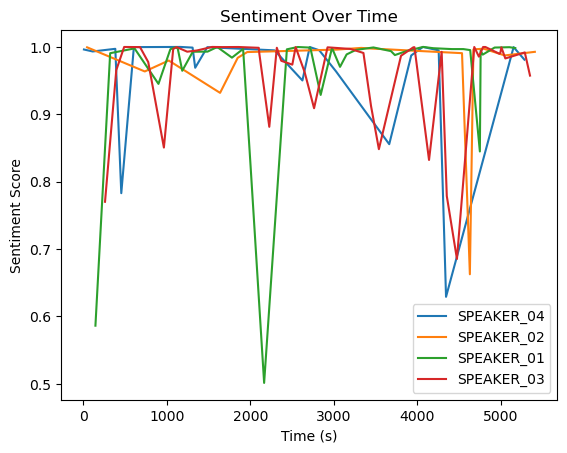

In [43]:
import matplotlib.pyplot as plt

# Sentiment over time
speaker_sentiments = defaultdict(list)
for segment in segments:
    if "sentiment" in segment:
        speaker_sentiments[segment["speaker_id"]].append((segment["start_time"], segment["sentiment_score"]))

# Plot sentiment over time
for speaker, sentiments in speaker_sentiments.items():
    times, scores = zip(*sentiments)
    plt.plot(times, scores, label=speaker)

plt.xlabel("Time (s)")
plt.ylabel("Sentiment Score")
plt.title("Sentiment Over Time")
plt.legend()
plt.show()

# Highlight Key Moments
Identify and highlight key moments in the debate, such as:

Heated exchanges: Segments with high sentiment intensity.

Frequently discussed topics: Topics mentioned by both speakers.

Fact-checked claims: Segments where the LLM provided strong verification or refutation.

In [44]:
# Find segments with high sentiment intensity
high_intensity_segments = [
    segment for segment in segments
    if "sentiment_score" in segment and abs(segment["sentiment_score"]) > 0.8
]

# Print high-intensity segments
for segment in high_intensity_segments:
    print(f"Speaker {segment['speaker_id']} at {segment['start_time']:.2f}s: {segment['text']}")

Speaker SPEAKER_04 at 6.16s: Dana and I will co-moderate this evening. Our job is to facilitate a debate between the two candidates tonight.
Speaker SPEAKER_02 at 43.75s: Should a candidate interrupt when his microphone is muted, he will be difficult to understand for viewers at home.
Speaker SPEAKER_04 at 110.98s: Let's begin the debate and let's start with the issue that voters consistently say is their top concern, the economy.
Speaker SPEAKER_01 at 320.13s: He's the only one who thinks that, I think.
Speaker SPEAKER_04 at 381.73s: I'm going to ask you a follow up.
Speaker SPEAKER_03 at 393.30s: It's just going to cause countries that have been ripping us off for years like China and many others, in all fairness to China,
Speaker SPEAKER_03 at 487.75s: And even after covid, it was so strong that we were able to get through covid much better than just about any other country.
Speaker SPEAKER_04 at 603.95s: President Biden, I want to give you an opportunity to respond to this question

# Generate a Debate Summary
Use an LLM to generate a concise summary of the debate, highlighting the key points, disagreements, and verified facts.

In [45]:
# Combine all text for the summary
debate_text = " ".join([segment["text"] for segment in segments if segment["text"]])

# Generate a summary using an LLM
summary_prompt = f"Summarize the following debate transcript in 5 bullet points:\n{debate_text}"
summary = llama_verify_fact(summary_prompt)

print("Debate Summary:")
print(summary)

Debate Summary:
Summarize the following debate transcript in 5 bullet points:
Dana and I will co-moderate this evening. Our job is to facilitate a debate between the two candidates tonight. Should a candidate interrupt when his microphone is muted, he will be difficult to understand for viewers at home. Let's begin the debate and let's start with the issue that voters consistently say is their top concern, the economy. We had an economy that was in freefall. We have never done so well. He's the only one who thinks that, I think. I'm going to ask you a follow up. It's just going to cause countries that have been ripping us off for years like China and many others, in all fairness to China, And according to a new nonpartisan analysis, President Trump, your administration approved eight point four trillion dollars in new debt And even after covid, it was so strong that we were able to get through covid much better than just about any other country. President Biden, I want to give you an o

# Create a Report
Combine all the insights into a comprehensive report, including:

Speaking time distribution.

Sentiment analysis.

Topic modeling results.

Fact-checking summary.

Key moments.

Debate summary.

In [ ]:
report = {
    "speaking_time": dict(speaker_time),
    "sentiment_analysis": speaker_sentiments,
    "topic_modeling": lda.components_,
    "fact_checking_summary": dict(verification_summary),
    "key_moments": high_intensity_segments,
    "debate_summary": summary
}

\

# Save the report
with open("debate_report.json", "w") as f:
    json.dump(report, f, indent=4)

AttributeError: 'collections.defaultdict' object has no attribute 'tolist'